In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

## Загрузка данных

In [2]:
ratings = pd.read_csv('../data/ml-latest-small/ratings.csv')
movies = pd.read_csv('../data/ml-latest-small/movies.csv')
tags = pd.read_csv('../data/ml-latest-small/tags.csv')

print(f"Размер ratings: {ratings.shape}")
print(f"Размер movies: {movies.shape}")
print(f"Размер tags: {tags.shape}")

Размер ratings: (100836, 4)
Размер movies: (9742, 3)
Размер tags: (3683, 4)


In [3]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [4]:
ratings.info()

<class 'pandas.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB


In [8]:
ratings.rating.unique()

array([4. , 5. , 3. , 2. , 1. , 4.5, 3.5, 2.5, 0.5, 1.5])

In [5]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [9]:
movies.info()

<class 'pandas.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   movieId  9742 non-null   int64
 1   title    9742 non-null   str  
 2   genres   9742 non-null   str  
dtypes: int64(1), str(2)
memory usage: 228.5 KB


In [6]:
tags.head()

,userId,movieId,tag,timestamp
0,2,60756,funny,1445714994
1,2,60756,Highly quotable,1445714996
2,2,60756,will ferrell,1445714992
3,2,89774,Boxing story,1445715207
4,2,89774,MMA,1445715200


In [10]:
tags.info()

<class 'pandas.DataFrame'>
RangeIndex: 3683 entries, 0 to 3682
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   userId     3683 non-null   int64
 1   movieId    3683 non-null   int64
 2   tag        3683 non-null   str  
 3   timestamp  3683 non-null   int64
dtypes: int64(3), str(1)
memory usage: 115.2 KB


## EDA

### 1. Оценки (ratings)

In [11]:
ratings['rating'].describe()

count    100836.000000
mean          3.501557
std           1.042529
min           0.500000
25%           3.000000
50%           3.500000
75%           4.000000
max           5.000000
Name: rating, dtype: float64

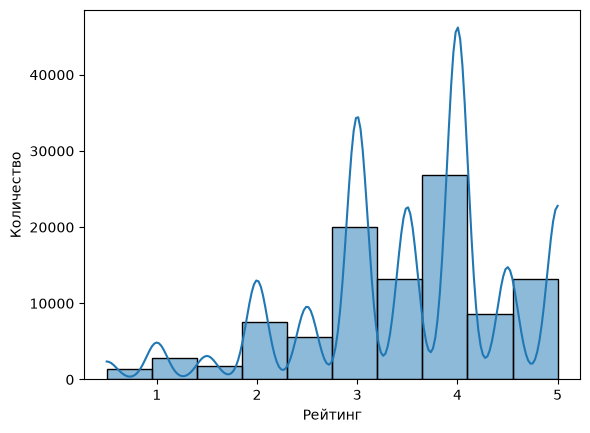

In [14]:
# Распределение оценок
sns.histplot(ratings['rating'], bins=10, kde=True)
plt.xlabel('Рейтинг')
plt.ylabel('Количество')
plt.show()

### 2. Активность пользователей

In [35]:
user_activity = ratings.groupby('userId')['rating'].count().sort_values(ascending=False)

In [36]:
user_activity

userId
414    2698
599    2478
474    2108
448    1864
274    1346
       ... 
442      20
278      20
147      20
320      20
53       20
Name: rating, Length: 610, dtype: int64

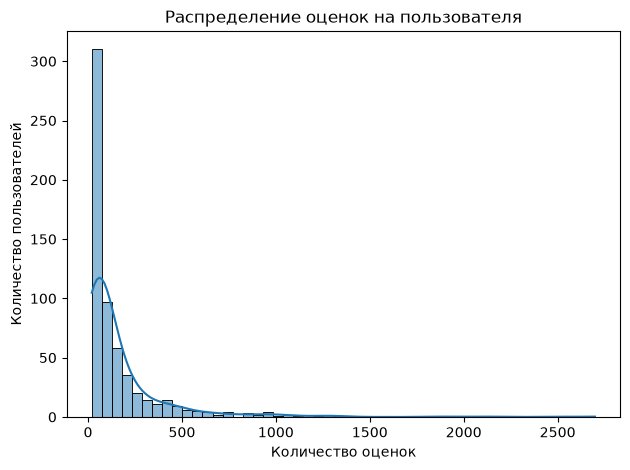

In [58]:
# Распределение активности
sns.histplot(user_activity, kde=True)
plt.title('Распределение оценок на пользователя', fontsize=12)
plt.xlabel('Количество оценок')
plt.ylabel('Количество пользователей')
plt.tight_layout()
plt.show()

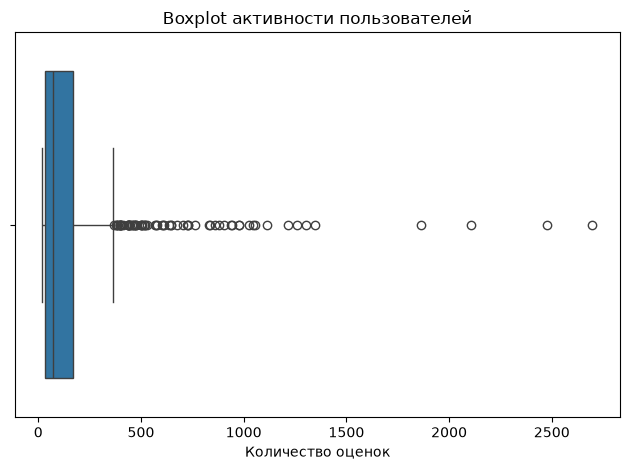

In [57]:
sns.boxplot(x=user_activity)
plt.title('Boxplot активности пользователей', fontsize=12)
plt.xlabel('Количество оценок')
plt.tight_layout()
plt.show()

### 3. Популярность фильмов

In [42]:
movie_popularity = ratings.groupby('movieId')['rating'].count().sort_values(ascending=False)
top_movies = movie_popularity.head(10)
top_movies_with_names = top_movies.reset_index().merge(movies[['movieId', 'title']], on='movieId')

In [62]:
movie_popularity

movieId
356       329
318       317
296       307
593       279
2571      278
         ... 
190207      1
190183      1
189713      1
189547      1
189381      1
Name: rating, Length: 9724, dtype: int64

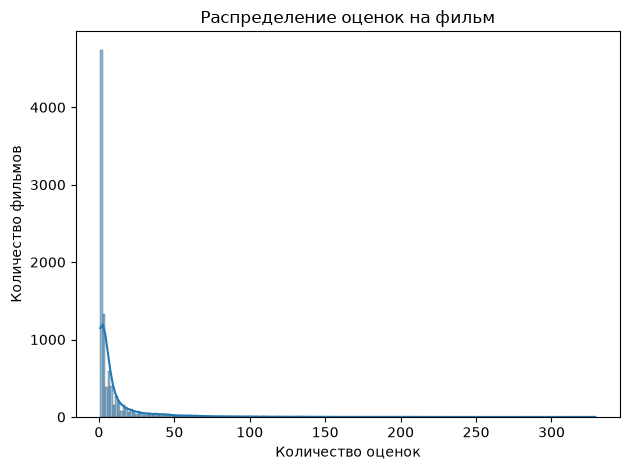

In [64]:
sns.histplot(movie_popularity, kde=True)
plt.title('Распределение оценок на фильм', fontsize=12)
plt.xlabel('Количество оценок')
plt.ylabel('Количество фильмов')
plt.tight_layout()
plt.show()

### 4. Популярность жанров

In [69]:
movies['genres_list'] = movies['genres'].str.split('|')
genres_exploded = movies.explode('genres_list')
genre_counts = genres_exploded['genres_list'].value_counts()

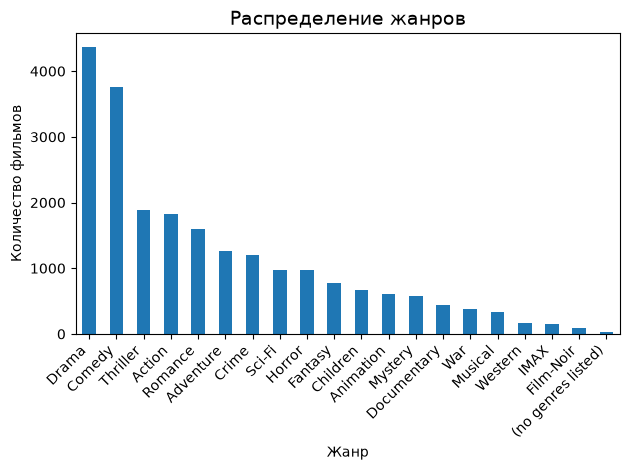

In [72]:
genre_counts.plot(kind='bar')
plt.title('Распределение жанров', fontsize=14)
plt.xlabel('Жанр')
plt.ylabel('Количество фильмов')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 5. Разреженность матрицы User-Item

In [74]:
user_item_matrix = ratings.pivot(index='userId', columns='movieId', values='rating')

In [76]:
# Разряженность матрицы
n_users = user_item_matrix.shape[0]
n_items = user_item_matrix.shape[1]
n_ratings = ratings.shape[0]
sparsity = 1 - (n_ratings / (n_users * n_items))

print(f"Разреженность матрицы: {sparsity:.2%}")

Разреженность матрицы: 98.30%


## Baseline 

In [80]:
# Разбиение на выборки
train_ratings, test_ratings = train_test_split(ratings, test_size=0.2, random_state=42)

print(f"Train size: {len(train_ratings)}")
print(f"Test size: {len(test_ratings)}")

Train size: 80668
Test size: 20168


В качестве baseline возьмём модель, которая прогнозирует самые популярные фильмы.

In [90]:
class PopularityRecommender:
    """Рекомендует самые популярные фильмы"""
    
    def __init__(self):
        self.popularity = None
        
    def fit(self, ratings):
        self.popularity = ratings.groupby('movieId')['rating'].count().sort_values(ascending=False)
        self.mean_ratings = ratings.groupby('movieId')['rating'].mean()
        
    def recommend(self, n=10):
        return self.popularity.head(n).index.tolist()
    
    def predict(self, movie_id):
        # Предсказывает оценку (средняя оценка фильма)
        return self.mean_ratings.get(movie_id, 3.0)

In [92]:
pop_model = PopularityRecommender()
pop_model.fit(train_ratings)

# Тестирование
recommendations = pop_model.recommend(n=5)
for movie_id in recommendations:
    movie_title = movies[movies['movieId'] == movie_id]['title'].values[0]
    print(f"  - {movie_title}")

  - Forrest Gump (1994)
  - Shawshank Redemption, The (1994)
  - Pulp Fiction (1994)
  - Silence of the Lambs, The (1991)
  - Matrix, The (1999)


В качестве упрощения оценим только по метрикам RMSE и MAE.

In [100]:
predictions = []
actuals = []

for _, row in test_ratings.iterrows():
    pred = pop_model.predict(row['movieId'])
    predictions.append(pred)
    actuals.append(row['rating'])

rmse = np.sqrt(mean_squared_error(actuals, predictions))
mae = mean_absolute_error(actuals, predictions)
print("Popularity Baseline Results:")
print(f"  RMSE: {rmse:.4f}")
print(f"  MAE:  {mae:.4f}")

Popularity Baseline Results:
  RMSE: 0.9827
  MAE:  0.7618
